In [15]:
# وارد کردن کتابخانه
import pandas as pd
# خواندن فایل فروش
sales = pd.read_csv(r"sales.csv")

In [2]:
# بررسی تعداد مقادیر خالی در هر ستون
print(sales.isnull().sum())

transaction_id    1
customer_id       0
age               0
gender            0
city              0
product           0
category          0
quantity          0
unit_price        0
discount          0
payment_method    0
created_at        0
dtype: int64


In [18]:
# بررسی تعداد ردیف‌های تکراری
print(sales.duplicated().sum())
# حذف ردیف‌های تکراری
sales = sales.drop_duplicates()

0


In [17]:
# تبدیل ستون‌ها به نوع داده مناسب
sales["transaction_id"] = pd.to_numeric(sales["transaction_id"], errors="coerce")
sales["customer_id"] = pd.to_numeric(sales["customer_id"], errors="coerce")
sales["age"] = pd.to_numeric(sales["age"], errors="coerce")
sales["gender"] = sales["gender"].map({"Male": True, "Female": False})
sales["city"] = sales["city"].astype("string")
sales["product"] = sales["product"].astype("string")
sales["category"] = sales["category"].astype("string")
sales["quantity"] = pd.to_numeric(sales["quantity"], errors="coerce")
sales["unit_price"] = pd.to_numeric(sales["unit_price"], errors="coerce")
sales["discount"] = pd.to_numeric(sales["discount"], errors="coerce")
sales["payment_method"] = sales["payment_method"].astype("string")
sales["created_at"] = pd.to_datetime(sales["created_at"], errors="coerce")

C:\Users\hp\AppData\Local\Temp\ipykernel_12012\3860087894.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales["created_at"] = pd.to_datetime(sales["created_at"], errors="coerce")


In [16]:
# بررسی تعداد مقادیر خالی در هر ستون بعد از تبدیل داده ها
print(sales.isnull().sum())

transaction_id    1
customer_id       0
age               0
gender            0
city              0
product           0
category          0
quantity          0
unit_price        0
discount          0
payment_method    0
created_at        0
dtype: int64


In [6]:

# بررسی تعداد ردیف‌های تکراری بعد از حذف
print(sales.duplicated().sum())
# حذف ردیف‌های تکراری بعد از حذف
sales = sales.drop_duplicates()

0


In [19]:
# حذف سن‌های نامعتبر
sales = sales[(sales["age"] > 0) & (sales["age"] <= 100)]

# حذف تعداد و قیمت‌های نامعتبر
sales = sales[(sales["quantity"] > 0) & (sales["unit_price"] > 0)]

# حذف درصد تخفیف نامعتبر
sales = sales[(sales["discount"] >= 0) & (sales["discount"] <= 100)]

# نمایش تعداد تاریخ‌های نامعتبر
print("Invalid dates:", sales["created_at"].isnull().sum())

Invalid dates: 0


In [20]:
# حذف سطرهایی که قسمت خالی دارند
sales = sales.dropna()

In [21]:
# نمایش نوع داده ستون‌ها
print(sales.dtypes)

transaction_id           float64
customer_id                int64
age                        int64
gender                      bool
city              string[python]
product           string[python]
category          string[python]
quantity                 float64
unit_price                 int64
discount                   int64
payment_method    string[python]
created_at        datetime64[ns]
dtype: object


In [22]:
# دیدن ستون مورد نیاز برای محاسبات
print(sales[["quantity", "unit_price", "discount", "amount"]].head(15))

KeyError: "['amount'] not in index"

In [ ]:
# محاسبه مبلغ نهایی
sales["amount"] = (sales["quantity"] * sales["unit_price"] * (1 - sales["discount"] / 100))

In [ ]:
# پیدا کردن شهر با بیشترین فروش
print(sales.groupby("city")["amount"].sum().sort_values(ascending=False))

# پیدا کردن محصول با بیشترین فروش
print(sales.groupby("product")["amount"].sum().sort_values(ascending=False))

# پیدا کردن دسته محصول با بیشترین فروش
print(sales.groupby("category")["amount"].sum().sort_values(ascending=False))

# شمارش تعداد استفاده از هر روش پرداخت
print(sales["payment_method"].value_counts())

# محاسبه میانگین مبلغ تراکنش
print(sales["amount"].mean())

# پیدا کردن مشتری با بیشترین مبلغ خرید
print(sales.groupby("customer_id")["amount"].sum().sort_values(ascending=False))

# پیدا کردن مشتری با بیشترین تعداد تراکنش
print(sales["customer_id"].value_counts())

# پیدا کردن محصول با بیشترین تعداد فروش
print(sales.groupby("product")["quantity"].sum().sort_values(ascending=False))

# محاسبه فروش بر اساس تاریخ
print(sales.groupby(sales["created_at"].dt.date)["amount"].sum())

# پیدا کردن شهر با بیشترین تعداد تراکنش
print(sales["city"].value_counts())

city
Ganja       2280.0
Baku        1275.0
Sumqayit      90.0
Name: amount, dtype: float64
product
Phone       2280.0
Laptop       900.0
Monitor      255.0
Mouse        120.0
Keyboard      90.0
Name: amount, dtype: float64
category
Electronics    3435.0
Accessories     210.0
Name: amount, dtype: float64
payment_method
Card      5
Cash      1
Online    1
Name: count, dtype: Int64
520.7142857142857
customer_id
102    2280.0
101    1020.0
104     255.0
103      90.0
Name: amount, dtype: float64
customer_id
101    3
102    2
103    1
104    1
Name: count, dtype: int64
product
Mouse       6.0
Phone       3.0
Keyboard    2.0
Laptop      2.0
Monitor     1.0
Name: quantity, dtype: float64
created_at
2001-09-26    1660.0
2002-09-26     150.0
2003-09-26     255.0
2004-09-26    1520.0
2007-09-26      60.0
Name: amount, dtype: float64
city
Baku        4
Ganja       2
Sumqayit    1
Name: count, dtype: Int64


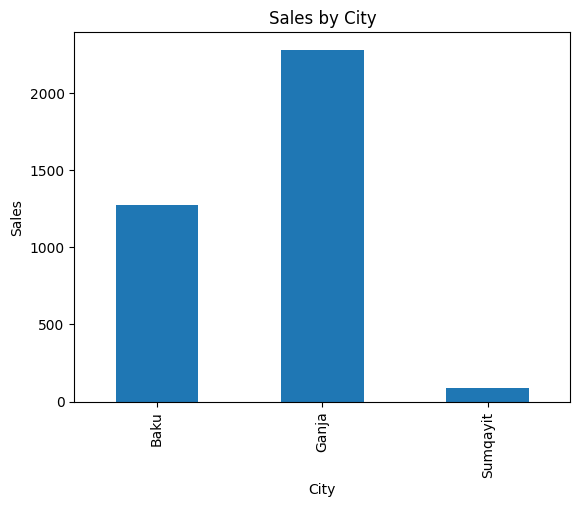

In [ ]:
# وارد کردن کتابخانه رسم نمودار
import matplotlib.pyplot as pt
# محاسبه فروش هر شهر
city_sales = sales.groupby("city")["amount"].sum()

# رسم نمودار فروش شهرها
city_sales.plot(kind="bar")
pt.title("Sales by City")
pt.xlabel("City")
pt.ylabel("Sales")
pt.show()


In [23]:
# محاسبه فروش هر دسته محصول
category_sales = sales.groupby("category")["amount"].sum()

# رسم نمودار فروش دسته‌های محصول
category_sales.plot(kind="bar")
pt.title("Sales by Category")
pt.xlabel("Category")
pt.ylabel("Sales")
pt.show()

KeyError: 'Column not found: amount'

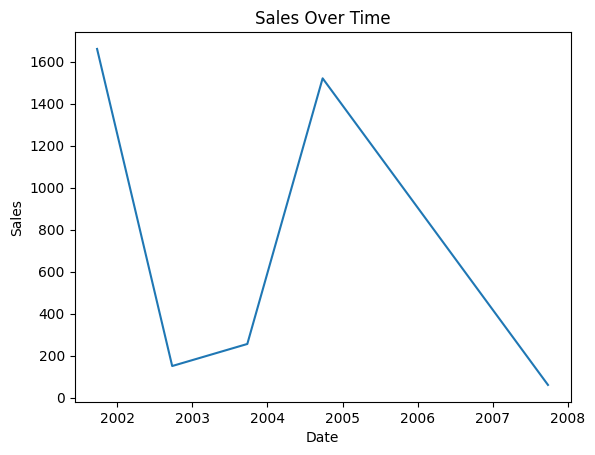

In [ ]:
# محاسبه فروش در طول زمان
daily_sales = sales.groupby(
    sales["created_at"].dt.date
)["amount"].sum()

# رسم نمودار فروش در طول زمان
daily_sales.plot(kind="line")
pt.title("Sales Over Time")
pt.xlabel("Date")
pt.ylabel("Sales")
pt.show()

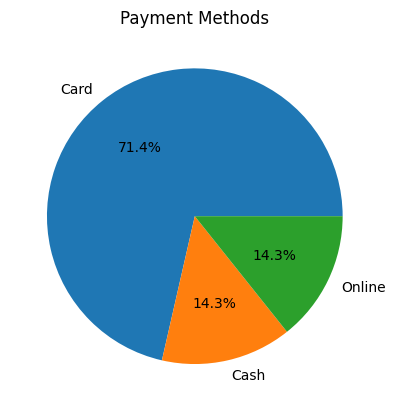

In [ ]:
# محاسبه روش های پرداخت
payment = sales["payment_method"].value_counts()

# رسم نمودار روش های پرداخت
payment.plot(kind="pie", autopct="%1.1f%%")
pt.title("Payment Methods")
pt.ylabel("")
pt.show()


In [ ]:
# پیدا کردن ۱۰ مشتری با بیشترین مبلغ خرید
top_customers = (
    sales.groupby("customer_id")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Customers:")
print(top_customers)

# بررسی محصولات خریداری‌شده توسط این مشتریان
customer_products = (
    sales[sales["customer_id"].isin(top_customers.index)]
    .groupby(["customer_id", "product"])["quantity"]
    .sum()
    .reset_index()
    .sort_values(["customer_id", "quantity"], ascending=[True, False])
)

print("\nSold Products:")
print(customer_products)

Top 10 Customers:
customer_id
102    2280.0
101    1020.0
104     255.0
103      90.0
Name: amount, dtype: float64

Sold Products:
   customer_id   product  quantity
1          101     Mouse       6.0
0          101    Laptop       2.0
2          102     Phone       3.0
3          103  Keyboard       2.0
4          104   Monitor       1.0


In [ ]:
# بررسی ارتباط تخفیف با تعداد تراکنش مشتریان
customer_behavior = sales.groupby("customer_id").agg(
    avg_discount=("discount", "mean"),
    transaction_count=("transaction_id", "count")
)

print(customer_behavior)

             avg_discount  transaction_count
customer_id                                 
101              3.333333                  3
102              5.000000                  2
103             10.000000                  1
104             15.000000                  1


In [ ]:
# ساخت جدول ویژگی‌های رفتاری مشتریان
customer_data = sales.groupby("customer_id").agg(
    total_spent=("amount", "sum"),
    transaction_count=("transaction_id", "count"),
    total_quantity=("quantity", "sum"),
    avg_transaction=("amount", "mean"),
    avg_discount=("discount", "mean")
)

print(customer_data)

             total_spent  transaction_count  total_quantity  avg_transaction  \
customer_id                                                                    
101               1020.0                  3             8.0            340.0   
102               2280.0                  2             3.0           1140.0   
103                 90.0                  1             2.0             90.0   
104                255.0                  1             1.0            255.0   

             avg_discount  
customer_id                
101              3.333333  
102              5.000000  
103             10.000000  
104             15.000000  


In [25]:
# انتخاب ویژگی‌هایی که برای دسته‌بندی مشتریان استفاده می‌شوند
features = customer_data[
    [
        "total_spent",
        "transaction_count",
        "total_quantity",
        "avg_transaction",
        "avg_discount"
    ]
]

NameError: name 'customer_data' is not defined

In [26]:
# وارد کردن ابزار استانداردسازی داده‌ها
from sklearn.preprocessing import StandardScaler as std

scaler = std()

scaled_features = scaler.fit_transform(features)

NameError: name 'features' is not defined

In [ ]:
# وارد کردن الگوریتم
from sklearn.cluster import KMeans
# ایجاد یک لیست برای ذخیره مقدار خطای هر تعداد خوشه
inertia = []
# بررسی تعداد خوشه‌ها از ۲ تا ۱۰
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # اجرای مدل روی داده‌های استانداردشده
    kmeans.fit(scaled_features)
    # ذخیره مقدار خطای مدل
    inertia.append(kmeans.inertia_)

pt.plot(range(2, 11), inertia, marker="o")
pt.xlabel("Number of Clusters")
pt.ylabel("Inertia")
pt.title("Elbow Method")
pt.show()

In [ ]:
# ذخیره داده‌های پاکسازی‌شده
sales.to_csv("clean_sales.csv", index=False)


In [ ]:
# خواندن فایل‌های بزرگ به صورت بخش‌های 100 هزار ردیفی
for chunk in pd.read_csv("sales.csv", chunksize=100000):
    print(chunk)

    transaction_id  customer_id  age  gender      city     product  \
0           1001.0          101   25    Male      Baku      Laptop   
1           1002.0          102   31  Female     Ganja       Phone   
2           1003.0          101   25    Male      Baku       Mouse   
3           1004.0          103   42  Female  Sumqayit    Keyboard   
4           1005.0          104   29    Male      Baku     Monitor   
5              NaN          105   35  Female      Baku  Headphones   
6           1007.0          102   31  Female     Ganja       Phone   
7           1008.0          106   27    Male      Baku      Laptop   
8           1009.0          107  150  Female      Baku      Tablet   
9           1010.0          108   22    Male     Ganja       Mouse   
10          1011.0          109   33  Female      Baku     Monitor   
11          1012.0          101   25    Male      Baku       Mouse   

       category quantity  unit_price  discount payment_method      created_at  
0   Elect